
HEAD (5 ROWS)
   rank                    Youtuber  subscribers   video views  \
0     1                    T-Series    245000000  2.280000e+11   
1     2              YouTube Movies    170000000  0.000000e+00   
2     3                     MrBeast    166000000  2.836884e+10   
3     4  Cocomelon - Nursery Rhymes    162000000  1.640000e+11   
4     5                   SET India    159000000  1.480000e+11   

           category                       Title  uploads        Country  \
0             Music                    T-Series    20082          India   
1  Film & Animation               youtubemovies        1  United States   
2     Entertainment                     MrBeast      741  United States   
3         Education  Cocomelon - Nursery Rhymes      966  United States   
4             Shows                   SET India   116536          India   

  Abbreviation   channel_type  ...  subscribers_for_last_30_days  \
0           IN          Music  ...                     2000000.0   
1

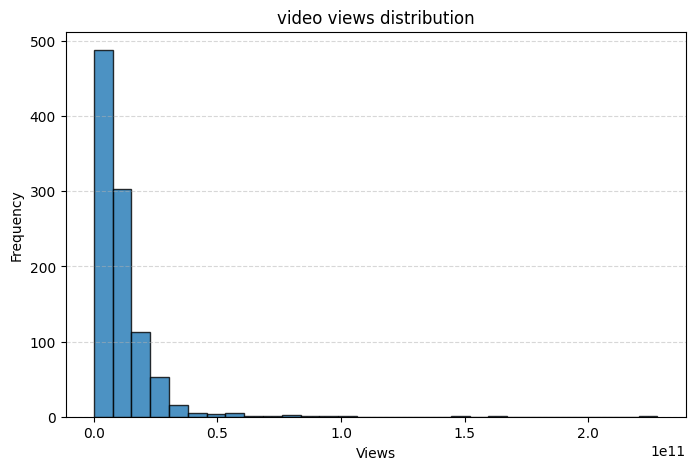


VIEWS SUMMARY
Max: 228000000000.0
Min: 0.0
Mean: 11039537052.03819

UPLOADS COLUMN: UPLOADS
Top country: India (3728212.0 uploads)

MAX UPLOADS
Youtuber    ABP NEWS
uploads     301308.0

MIN UPLOADS
Youtuber    Music
uploads       0.0


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "/content/GlobalYouTubeStatistics.csv"

# Load data
df = pd.read_csv(DATA_PATH, encoding="latin-1")

def print_h(title):
    print(f"\n{title.upper()}")

print_h("head (5 rows)")
print(df.head())

print_h("dataset shape")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print_h("missing values (initial)")
missing_init = df.isna().sum()
print(missing_init[missing_init > 0].sort_values(ascending=False))

# Clean missing/null strings
nulls = ["", " ", "None", "null", "NULL", "NaN"]
df.replace(nulls, np.nan, inplace=True)

# Convert columns to numeric where possible
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except (ValueError, TypeError):
        continue

# Fill numeric NAs with mean
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean()).astype(float)

print_h("missing values (after imputation)")
missing_imputed = df.isna().sum()
print(missing_imputed[missing_imputed > 0].sort_values(ascending=False))

print_h("columns list")
print(list(df.columns))

print_h("unique countries count")
print(df['Country'].nunique())


#VIEWS
views_cols = [c for c in df.columns if "view" in c.lower()]

if not views_cols:
    print("\nWARNING: No 'view' column found.")
else:
    v_col = views_cols[0]
    print_h(f"views column: {v_col}")

    plt.figure(figsize=(8, 5))
    df[v_col].plot(kind='hist', bins=30, color='#1f77b4', edgecolor='black', alpha=0.8)
    plt.title(f"{v_col} distribution")
    plt.xlabel("Views")
    plt.ylabel("Frequency")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

    print_h("views summary")
    print(f"Max: {df[v_col].max()}")
    print(f"Min: {df[v_col].min()}")
    print(f"Mean: {df[v_col].mean()}")


#UPLOADS
up_cols = [c for c in df.columns if "upload" in c.lower()]

if not up_cols:
    print("\nWARNING: No 'upload' column found.")
else:
    u_col = up_cols[0]
    print_h(f"uploads column: {u_col}")

    country_up = df.groupby("Country")[u_col].sum()
    best_country = country_up.idxmax()
    best_val = country_up.max()

    print(f"Top country: {best_country} ({best_val} uploads)")

    name_keys = ["youtuber", "channel", "title", "name"]
    name_cols = [c for c in df.columns if any(k in c.lower() for k in name_keys)]

    if not name_cols:
        print("\nWARNING: No name column found.")
    else:
        n_col = name_cols[0]

        idx_max = df[u_col].idxmax()
        idx_min = df[u_col].idxmin()

        print_h("max uploads")
        print(df.loc[idx_max, [n_col, u_col]].to_string())

        print_h("min uploads")
        print(df.loc[idx_min, [n_col, u_col]].to_string())

In [10]:
import pandas as pd
import numpy as np

DATA_PATH = "/content/bestsellerswithcategories.csv"

df = pd.read_csv(DATA_PATH)

def print_h(title):
    print(f"\n{title.upper()}")

# 2. First 10 rows
print_h("first 10 rows")
print(df.head(10))

# 3. Dataset shape
print_h("dataset shape")
print(f"Shape: {df.shape}")
print(f"How many books (rows) are stored in the dataset? {df.shape[0]}")

# 4. Change column names
df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']
print_h("renamed columns")
print(list(df.columns))

# 5. Missing values
print_h("missing values check")
missing = df.isna().sum()
print(missing)

has_missing = "Yes" if missing.sum() > 0 else "No"
print(f"Are there any missing values in the variables? {has_missing}")

# 6. Unique genres
print_h("unique genres")
unique_genres = df['genre'].unique()
print(f"What are the unique genres? {list(unique_genres)}")

# 7. Price analysis
print_h("price stats")
print(f"Max price: {df['price'].max()}")
print(f"Min price: {df['price'].min()}")
print(f"Mean price: {df['price'].mean()}")
print(f"Median price: {df['price'].median()}")

# 8. Searching and sorting data
print_h("search and sort answers")

max_rating = df['user_rating'].max()
print(f"Highest rating in the dataset? {max_rating}")

top_rating_count = df[df['user_rating'] == max_rating].shape[0]
print(f"How many books have this highest rating? {top_rating_count}")

most_reviews_idx = df['reviews'].idxmax()
most_reviews_book = df.loc[most_reviews_idx, 'name']
print(f"Which book has the most reviews? {most_reviews_book}")

books_2010 = df[df['year'] == 2010]
exp_2010_idx = books_2010['price'].idxmax()
exp_2010_book = df.loc[exp_2010_idx, 'name']
print(f"Most expensive book among the Top 50 in 2010? {exp_2010_book}")

fiction_2012_count = df[(df['genre'] == 'Fiction') & (df['year'] == 2012)].shape[0]
print(f"How many Fiction books in the Top 50 in 2012? {fiction_2012_count}")

top_rated_10_11 = df[(df['user_rating'] == 4.9) & (df['year'].isin([2010, 2011]))].shape[0]
print(f"How many books with a 4.9 rating in 2010 and 2011? {top_rated_10_11}")

# 9. Max and min price by genre using groupby and agg
print_h("min and max price by genre")
genre_stats = df[['genre', 'price']].groupby('genre').agg(['min', 'max'])
print(genre_stats)


FIRST 10 ROWS
                                                Name  \
0                      10-Day Green Smoothie Cleanse   
1                                  11/22/63: A Novel   
2            12 Rules for Life: An Antidote to Chaos   
3                             1984 (Signet Classics)   
4  5,000 Awesome Facts (About Everything!) (Natio...   
5      A Dance with Dragons (A Song of Ice and Fire)   
6  A Game of Thrones / A Clash of Kings / A Storm...   
7                     A Gentleman in Moscow: A Novel   
8      A Higher Loyalty: Truth, Lies, and Leadership   
9                          A Man Called Ove: A Novel   

                     Author  User Rating  Reviews  Price  Year        Genre  
0                  JJ Smith          4.7    17350      8  2016  Non Fiction  
1              Stephen King          4.6     2052     22  2011      Fiction  
2        Jordan B. Peterson          4.7    18979     15  2018  Non Fiction  
3             George Orwell          4.7    21424      6